In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as sci

In [3]:
# define our system (SIR)

# x = [S,I,R]
def SIR(x,t, beta, mu, gamma, N, v):
    S,I,R = x
    dSdt = (mu * N) - ((beta * I * S) / N) - (mu * S) - (v * S) # birth - recovery - death - vaccinated
    dIdt = (beta * I * (S/N)) - (gamma * I) - (mu * I) # infection - recovery - death
    dRdt = (gamma * I) - (mu * R) + (v * S) # recovery - death + vaccinated
    return [dSdt, dIdt, dRdt]

In [4]:
# params, time units of days

mu = 0 # for now we have as beta as 0, (closed infection: no one is born, no one dies within our model)
gamma = 1 / 7 # recovery rate (usually will be recovered by 7 days)
beta = 0.5 # deaths
N = 1000 # number of people
v = 0.01

I0 = 1
R0 = 0
S0 = N - I0 - R0

In [5]:
time_vals = np.linspace(0,90,10000) # timesteps is 10000
sol = sci.odeint(SIR, [S0, I0, R0], time_vals, args=(beta, mu, gamma, N, v))
S,I,R = sol.T

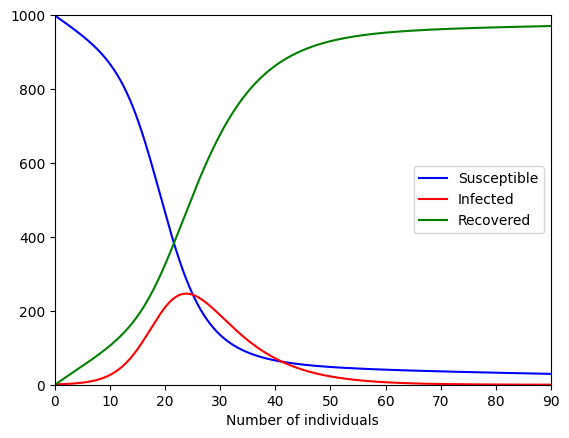

In [ ]:
plt.plot(time_vals, S, label = "Susceptible", color="blue")
plt.plot(time_vals, I, label = "Infected", color="red")
plt.plot(time_vals, R, label = "Recovered", color="green")
plt.xlabel("Time (days)")
plt.xlabel("Number of individuals")
plt.xlim(0,90)
plt.ylim(0,N)
plt.legend()
plt.show()